In [ ]:
import pandas as pd
import numpy as np
from collections import deque
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Read in the data (update path as needed)
df = pd.read_csv('fadml_dummy.csv')  # Assuming the CSV is in the same directory

# Feature selection
features = ["step", "amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

# Split data into training and test sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Prepare training data
X_train = train_df[features]
y_train = train_df["isFraud"]

# Prepare test data
X_test = test_df[features]
y_test = test_df["isFraud"]

In [ ]:
# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Original training set shape:", X_train.shape, y_train.shape)
print("Resampled training set shape:", X_train_resampled.shape, y_train_resampled.shape)

In [ ]:
# Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train_resampled, y_train_resampled)

y_pred_dtc = dtc.predict(X_test)

# Calculate metrics
accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
precision_dtc = precision_score(y_test, y_pred_dtc)
recall_dtc = recall_score(y_test, y_pred_dtc)
f1_dtc = f1_score(y_test, y_pred_dtc)

print("Decision Tree Metrics:")
print(f"Accuracy: {accuracy_dtc:.4f}")
print(f"Precision: {precision_dtc:.4f}")
print(f"Recall: {recall_dtc:.4f}")
print(f"F1 Score: {f1_dtc:.4f}")

# Confusion Matrix
conf_matrix_dtc = confusion_matrix(y_test, y_pred_dtc)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_dtc, display_labels=["Not Fraud", "Fraud"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Decision Tree Confusion Matrix")
plt.show()

Accuracy: 0.9205273759384728


Accuracy: 0.9340780076908991
Precision: 0.6078947368421053
Recall: 0.5226244343891403
F1 Score: 0.5620437956204379


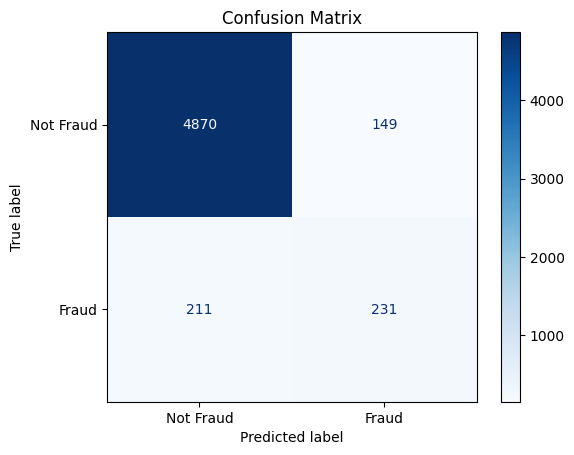

In [ ]:
# Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf.predict(X_test)

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Metrics:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")

# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_rf, display_labels=["Not Fraud", "Fraud"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Random Forest Confusion Matrix")
plt.show()

Accuracy: 0.9190624427760483
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


c:\Users\robin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


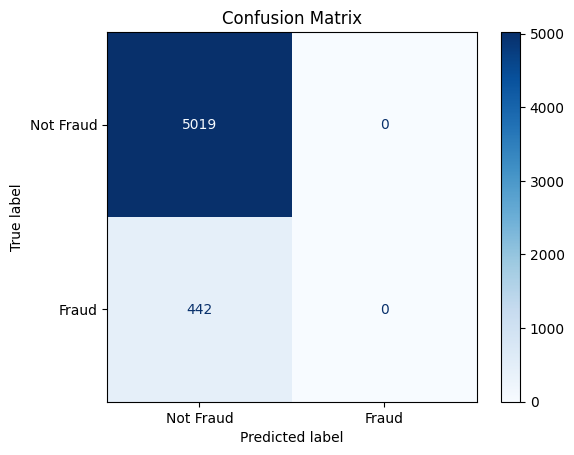

In [ ]:
# SVM Classifier
svc = svm.SVC(kernel='rbf', random_state=42)
svc.fit(X_train_resampled, y_train_resampled)

y_pred_svc = svc.predict(X_test)

# Calculate metrics
accuracy_svc = accuracy_score(y_test, y_pred_svc)
precision_svc = precision_score(y_test, y_pred_svc)
recall_svc = recall_score(y_test, y_pred_svc)
f1_svc = f1_score(y_test, y_pred_svc)

print("SVM Metrics:")
print(f"Accuracy: {accuracy_svc:.4f}")
print(f"Precision: {precision_svc:.4f}")
print(f"Recall: {recall_svc:.4f}")
print(f"F1 Score: {f1_svc:.4f}")

# Confusion Matrix
conf_matrix_svc = confusion_matrix(y_test, y_pred_svc)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_svc, display_labels=["Not Fraud", "Fraud"])
disp.plot(cmap=plt.cm.Blues)
plt.title("SVM Confusion Matrix")
plt.show()

In [ ]:
# Graph-based Fraud Detection using BFS
# Create a graph with nodes representing account IDs and edges representing transactions
graph = {}
for _, row in df.iterrows():
    src = row["nameOrig"]
    dest = row["nameDest"]
    amount = row["amount"]
    oldbalanceOrg = row["oldbalanceOrg"]
    oldbalanceDest = row["oldbalanceDest"]
    is_fraud = row["isFraud"]
    
    # Add edge to the graph
    if src not in graph:
        graph[src] = []
    graph[src].append((dest, amount, oldbalanceOrg, oldbalanceDest, is_fraud))

# Run BFS to detect suspicious transaction patterns
num_runs = 10  # Reduced for efficiency
all_fraud_transactions = []
for i in range(num_runs):
    # Randomly choose a starting node that has an outgoing edge with isFraud == 1
    start_nodes = [src for src in graph if any(is_fraud == 1 for _, _, _, _, is_fraud in graph[src])]
    if not start_nodes:
        continue
    start = np.random.choice(start_nodes)

    visited = set()
    queue = deque([(start, 0)])
    fraud_transactions = []
    while queue:
        vertex, depth = queue.popleft()
        if vertex in visited:
            continue
        visited.add(vertex)

        # Flag transactions as suspicious based on criteria
        for dest, amount, oldbalanceOrg, oldbalanceDest, is_fraud in graph.get(vertex, []):
            if is_fraud == 1 and amount > 10000 and amount > 0.75 * oldbalanceOrg and amount > 0.75 * oldbalanceDest:
                fraud_transactions.append({
                    "start_node": vertex, 
                    "end_node": dest, 
                    "amount": amount, 
                    "depth": depth
                })

        # Explore neighboring accounts (limit depth to avoid infinite loops)
        if depth < 3:
            for dest, amount, oldbalanceOrg, oldbalanceDest, is_fraud in graph.get(vertex, []):
                if dest not in visited:
                    queue.append((dest, depth + 1))

    all_fraud_transactions.extend(fraud_transactions)

# Convert to DataFrame and display results
fraud_df = pd.DataFrame(all_fraud_transactions)
print("Detected suspicious transactions:")
print(fraud_df.head())
print(f"Total suspicious transactions detected: {len(fraud_df)}")

Accuracy: 0.9190624427760483
